# Breast Cancer Prediction using different ML models

### Importing all the important packages

In [2]:
# for basic Data Visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px

## All Machine learning model packages 

In [3]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_curve, 
    auc, 
    precision_recall_curve, 
    average_precision_score
)

## Read the Data 

In [4]:
data = pd.read_csv('data.csv')

In [5]:
data.columns = data.columns.str.replace('x.', '', regex=False)

In [6]:
data.head()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_pts_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_pts_worst,symmetry_worst,fractal_dim_worst,diagnosis
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


###  Removing the id  column from the data

In [7]:
data.drop(['id'], axis=1, inplace=True)
data.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_pts_mean,symmetry_mean,fractal_dim_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_pts_worst,symmetry_worst,fractal_dim_worst,diagnosis
0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   radius_mean        569 non-null    float64
 1   texture_mean       569 non-null    float64
 2   perimeter_mean     569 non-null    float64
 3   area_mean          569 non-null    float64
 4   smoothness_mean    569 non-null    float64
 5   compactness_mean   569 non-null    float64
 6   concavity_mean     569 non-null    float64
 7   concave_pts_mean   569 non-null    float64
 8   symmetry_mean      569 non-null    float64
 9   fractal_dim_mean   569 non-null    float64
 10  radius_se          569 non-null    float64
 11  texture_se         569 non-null    float64
 12  perimeter_se       569 non-null    float64
 13  area_se            569 non-null    float64
 14  smoothness_se      569 non-null    float64
 15  compactness_se     569 non-null    float64
 16  concavity_se       569 non

In [9]:
data.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_pts_mean,symmetry_mean,fractal_dim_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_pts_worst,symmetry_worst,fractal_dim_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [10]:
data.isna().sum()

radius_mean          0
texture_mean         0
perimeter_mean       0
area_mean            0
smoothness_mean      0
compactness_mean     0
concavity_mean       0
concave_pts_mean     0
symmetry_mean        0
fractal_dim_mean     0
radius_se            0
texture_se           0
perimeter_se         0
area_se              0
smoothness_se        0
compactness_se       0
concavity_se         0
concave_pts_se       0
symmetry_se          0
fractal_dim_se       0
radius_worst         0
texture_worst        0
perimeter_worst      0
area_worst           0
smoothness_worst     0
compactness_worst    0
concavity_worst      0
concave_pts_worst    0
symmetry_worst       0
fractal_dim_worst    0
diagnosis            0
dtype: int64

In [11]:
data.describe().T.style.background_gradient(cmap = sns.color_palette("ch:s=-.2,r=.6", as_cmap=True))

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.000000,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.110000
texture_mean,569.000000,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.280000
perimeter_mean,569.000000,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.500000
area_mean,569.000000,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.000000
smoothness_mean,569.000000,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.163400
compactness_mean,569.000000,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.345400
concavity_mean,569.000000,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.426800
concave_pts_mean,569.000000,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.201200
symmetry_mean,569.000000,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.304000
fractal_dim_mean,569.000000,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.097440


In [12]:
data['diagnosis'].value_counts()


B    357
M    212
Name: diagnosis, dtype: int64

In [13]:
px.histogram(data_frame=data, x='diagnosis', color='diagnosis',color_discrete_sequence=['#A865C9','#f6abb6'])

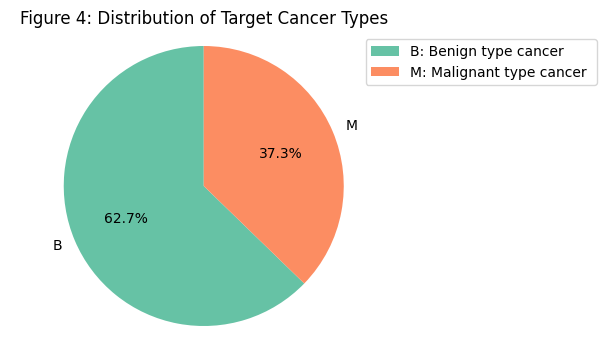

In [14]:

Target = data['diagnosis'].value_counts()
plt.figure(figsize=(5, 4))
plt.dpi = 150
plt.pie(Target, labels=Target.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
plt.title('Figure 4: Distribution of Target Cancer Types')
plt.axis('equal')  
plt.legend(['B: Benign type cancer ','M: Malignant type cancer '],loc="best",bbox_to_anchor=(0.9, 1))
plt.show()

## Pair Plot for Mean Values of different parameters

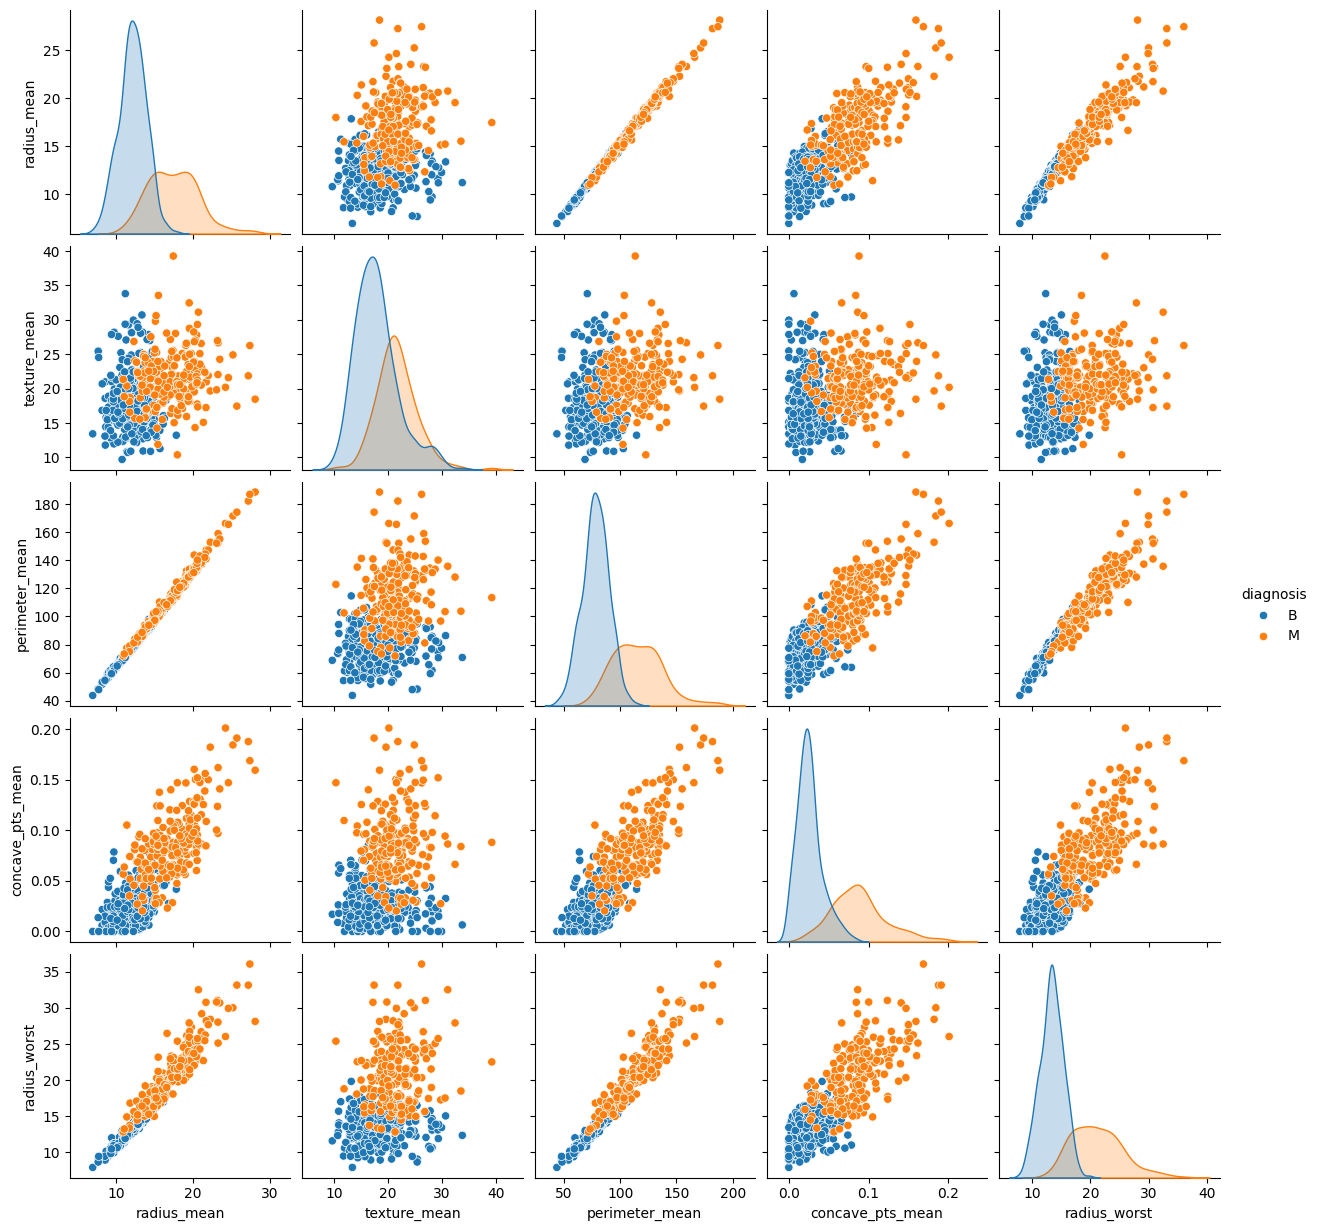

In [15]:
sns.pairplot(data[['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'concave_pts_mean', 'radius_worst']], hue='diagnosis') 
plt.show()

## Data Conversion for Model

In [16]:
data = data.drop(['Unnamed: 32'], axis=1, errors='ignore') 

le = LabelEncoder()
data['diagnosis'] = le.fit_transform(data['diagnosis'])

X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Prediction on the Given Dataset

 Base Models (Default Parameters) 
Logistic Reg    | Train Acc: 0.9868 | Test Acc: 0.9649
Decision Tree   | Train Acc: 1.0000 | Test Acc: 0.9298
Random Forest   | Train Acc: 1.0000 | Test Acc: 0.9737
SVM             | Train Acc: 0.9868 | Test Acc: 0.9737
KNN             | Train Acc: 0.9780 | Test Acc: 0.9561


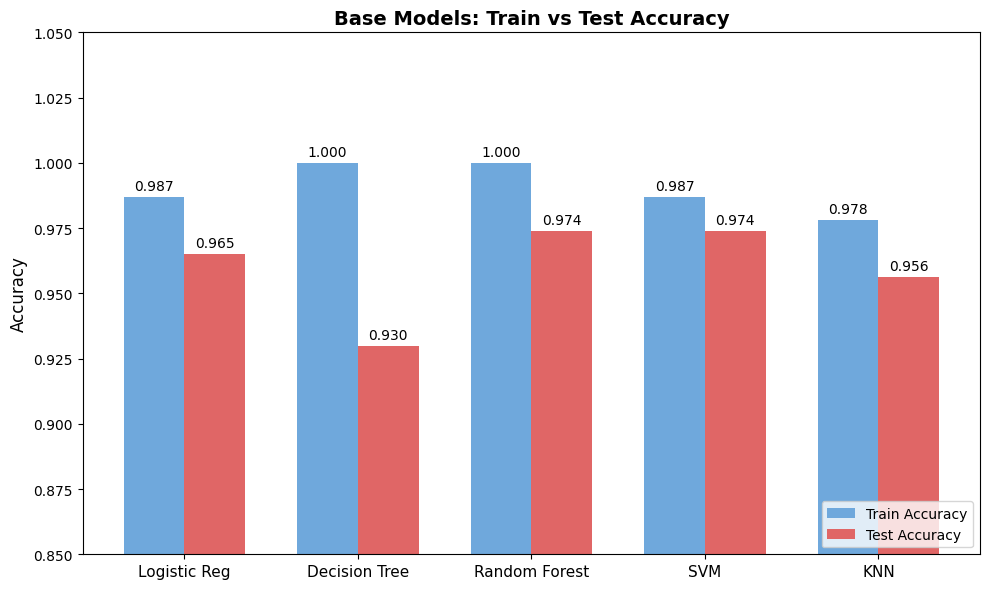

In [17]:
# Initialize models
models = {
    'Logistic Reg': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42), 
    'KNN': KNeighborsClassifier()
}
base_train_acc = []
base_test_acc = []
model_names = list(models.keys())

# Train and evaluate base models
print(" Base Models (Default Parameters) ")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    base_train_acc.append(train_acc)
    base_test_acc.append(test_acc)
    print(f"{name.ljust(15)} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")


def plot_comparison(train_scores, test_scores, title):
    x = np.arange(len(model_names))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, train_scores, width, label='Train Accuracy', color='#6fa8dc')
    rects2 = ax.bar(x + width/2, test_scores, width, label='Test Accuracy', color='#e06666')
    
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=11)
    ax.legend(loc='lower right')
    ax.set_ylim([0.85, 1.05])
    
    
    for rects in [rects1, rects2]:
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.3f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()

# Plot the base model results
plot_comparison(base_train_acc, base_test_acc, 'Base Models: Train vs Test Accuracy')

## Model Prediction Using the HyperParameter Tuning


 Tuned Models (Optimized Parameters) 
Logistic Reg    | Train Acc: 0.9868 | Test Acc: 0.9649 | Best Params: {'C': 1}
Decision Tree   | Train Acc: 0.9868 | Test Acc: 0.9211 | Best Params: {'max_depth': 5, 'min_samples_split': 2}
Random Forest   | Train Acc: 0.9978 | Test Acc: 0.9737 | Best Params: {'max_depth': 7, 'n_estimators': 50}
SVM             | Train Acc: 0.9868 | Test Acc: 0.9737 | Best Params: {'C': 1, 'kernel': 'rbf', 'probability': True}
KNN             | Train Acc: 0.9846 | Test Acc: 0.9386 | Best Params: {'n_neighbors': 3}


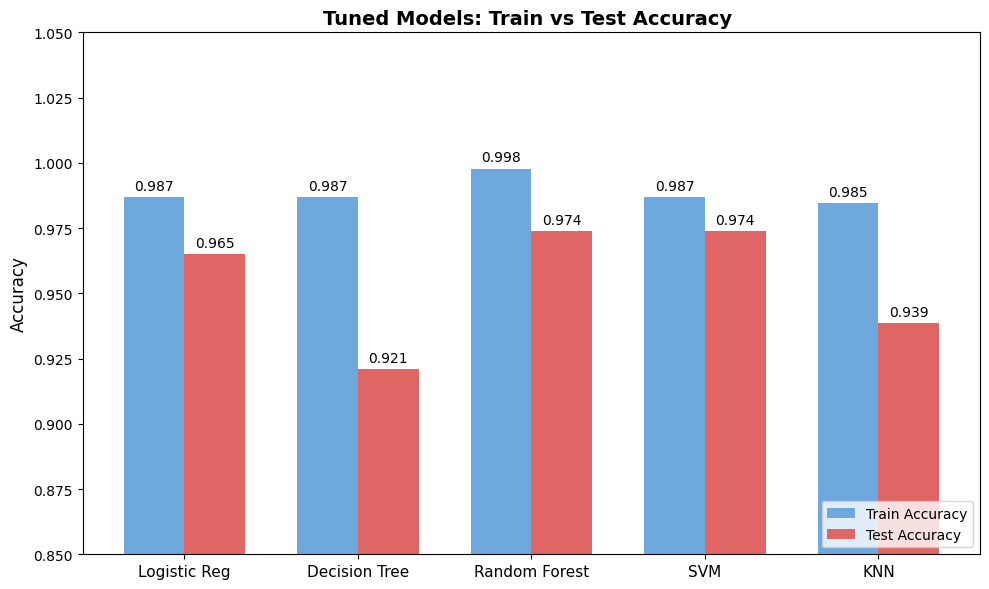

In [18]:
tuned_train_acc = []
tuned_test_acc = []

# Define grid search parameters for optimization
grids = {
    'Logistic Reg': {'C': [0.01, 0.1, 1, 10]},
    'Decision Tree': {'max_depth': [3, 4, 5], 'min_samples_split': [2, 5, 10]},
    'Random Forest': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7]},
    'SVM': {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf'], 'probability': [True]}, 
    'KNN': {'n_neighbors': [3, 5, 7, 9]}
}

print("\n Tuned Models (Optimized Parameters) ")
for name in model_names:
    grid = grids[name]
    model = models[name]
    
    # 5-Fold Cross Validation
    clf = GridSearchCV(model, grid, cv=5, scoring='accuracy', n_jobs=-1)
    clf.fit(X_train_scaled, y_train)
    best_model = clf.best_estimator_
    
    train_pred = best_model.predict(X_train_scaled)
    test_pred = best_model.predict(X_test_scaled)
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    tuned_train_acc.append(train_acc)
    tuned_test_acc.append(test_acc)
    print(f"{name.ljust(15)} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | Best Params: {clf.best_params_}")

# Plot the tuned model results
plot_comparison(tuned_train_acc, tuned_test_acc, 'Tuned Models: Train vs Test Accuracy ')

## Plot Comparison with Base Test Acc vs Tuned Test Acc

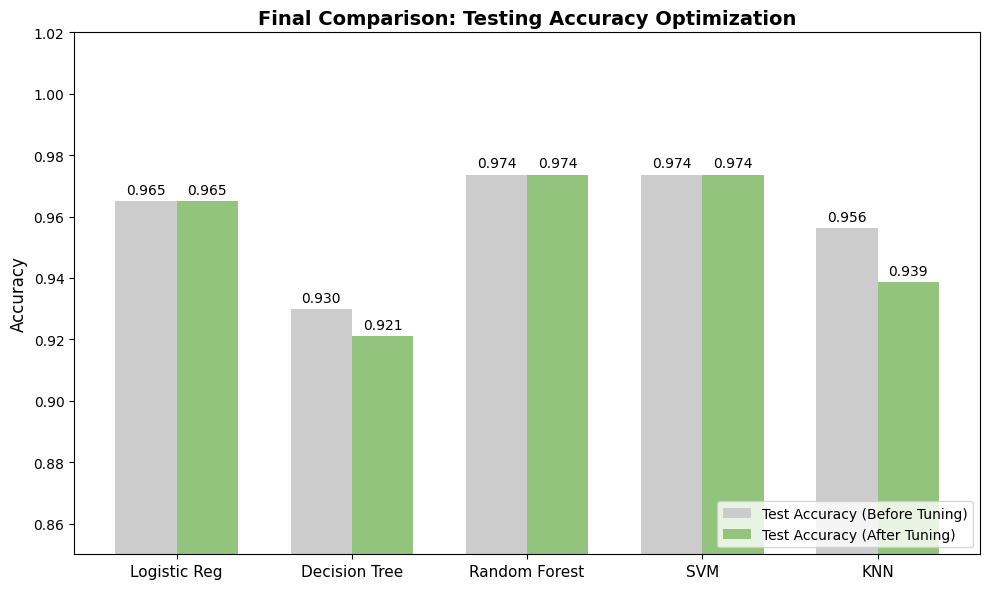

In [19]:

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(model_names))
width = 0.35

rects1 = ax.bar(x - width/2, base_test_acc, width, label='Test Accuracy (Before Tuning)', color='#cccccc')
rects2 = ax.bar(x + width/2, tuned_test_acc, width, label='Test Accuracy (After Tuning)', color='#93c47d')

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Final Comparison: Testing Accuracy Optimization', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.legend(loc='lower right')
ax.set_ylim([0.85, 1.02])

for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## Showing the Precision Recall and F-1 Score of the Base models and Tuned models

In [20]:
metrics_data = []


for name in models.keys():
    
    # Base Models
    base_model = models[name]
    
    base_model.fit(X_train_scaled, y_train) 
    base_pred = base_model.predict(X_test_scaled) 
    
    base_prec = precision_score(y_test, base_pred)
    base_rec = recall_score(y_test, base_pred)
    base_f1 = f1_score(y_test, base_pred)
    
    # Tuned Models
    grid = grids[name]
    clf = GridSearchCV(models[name], grid, cv=5, scoring='accuracy', n_jobs=-1)
    clf.fit(X_train_scaled, y_train)
    tuned_best_model = clf.best_estimator_
    
    tuned_pred = tuned_best_model.predict(X_test_scaled)
    
    tuned_prec = precision_score(y_test, tuned_pred)
    tuned_rec = recall_score(y_test, tuned_pred)
    tuned_f1 = f1_score(y_test, tuned_pred)
    

    metrics_data.append({
        'Model': name,
        'Base Precision': round(base_prec, 4),
        'Tuned Precision': round(tuned_prec, 4),
        'Base Recall': round(base_rec, 4),
        'Tuned Recall': round(tuned_rec, 4),
        'Base F1-Score': round(base_f1, 4),
        'Tuned F1-Score': round(tuned_f1, 4)
    })


metrics_df = pd.DataFrame(metrics_data)


metrics_df.set_index('Model', inplace=True)

print("\n Precision, Recall, and F1-Score Table ")
display(metrics_df)


 Precision, Recall, and F1-Score Table 


,Base Precision,Tuned Precision,Base Recall,Tuned Recall,Base F1-Score,Tuned F1-Score
Model,,,,,,
Logistic Reg,0.9750,0.9750,0.9286,0.9286,0.9512,0.9512
Decision Tree,0.9048,0.9459,0.9048,0.8333,0.9048,0.8861
Random Forest,1.0000,1.0000,0.9286,0.9286,0.9630,0.9630
SVM,1.0000,1.0000,0.9286,0.9286,0.9630,0.9630
KNN,0.9744,0.9730,0.9048,0.8571,0.9383,0.9114


## Plotting the ROC and AUC Curves of the base vs tuned models

In [21]:
base_results = {}
tuned_results = {}


for name in models.keys():

    #  Base Model
    base_model = models[name]
    base_model.fit(X_train_scaled, y_train)
    
    # Get probabilities for class 1 (Malignant) Base model
    base_prob = base_model.predict_proba(X_test_scaled)[:, 1]
    
    base_results[name] = {
        'prob': base_prob
    }
    
    #  Tuned Model
    clf = GridSearchCV(models[name], grids[name], cv=5, scoring='accuracy', n_jobs=-1)
    clf.fit(X_train_scaled, y_train)
    best_model = clf.best_estimator_
    
    # Get probabilities for class 1 (Malignant) Tuned model
    tuned_prob = best_model.predict_proba(X_test_scaled)[:, 1]
    
    tuned_results[name] = {
        'prob': tuned_prob
    }


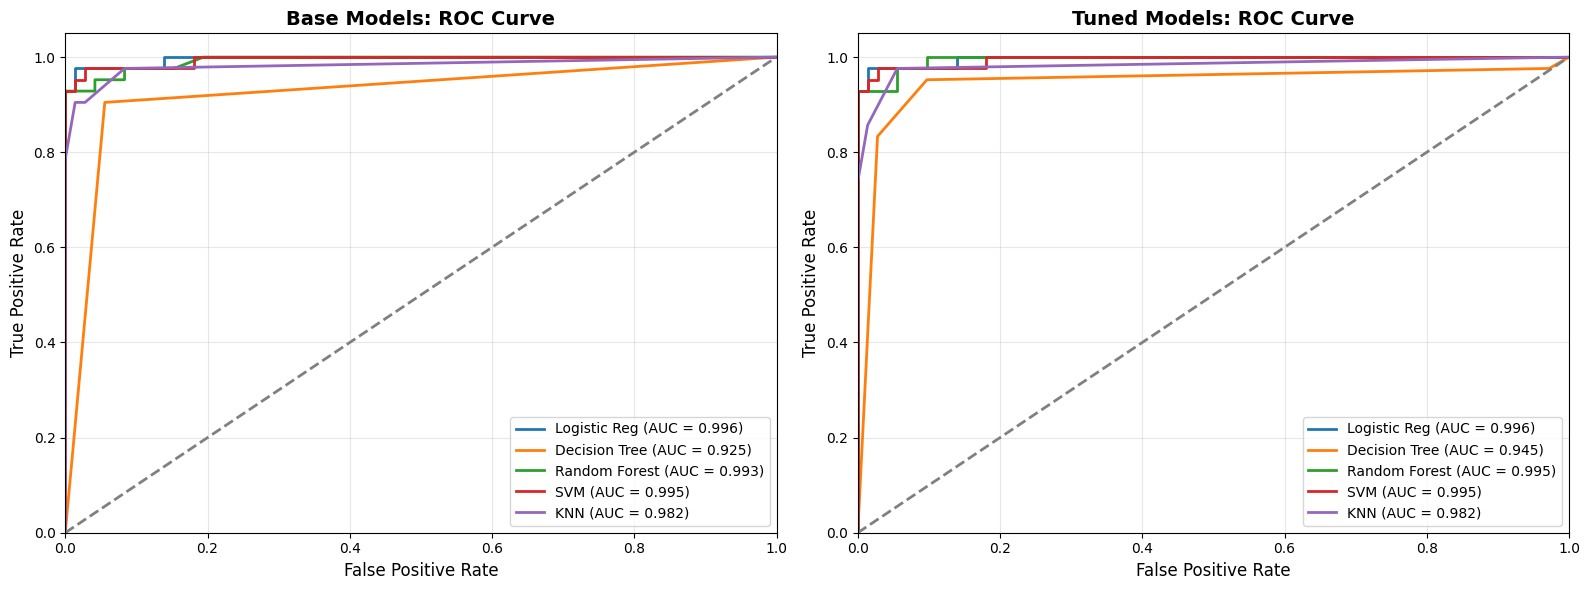

In [22]:
def plot_roc_curves(base_res, tuned_res, y_true):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    for name in base_res.keys():
        # Base ROC
        fpr_b, tpr_b, _ = roc_curve(y_true, base_res[name]['prob'])
        roc_auc_b = auc(fpr_b, tpr_b)
        axes[0].plot(fpr_b, tpr_b, lw=2, label=f'{name} (AUC = {roc_auc_b:.3f})')
        
        # Tuned ROC
        fpr_t, tpr_t, _ = roc_curve(y_true, tuned_res[name]['prob'])
        roc_auc_t = auc(fpr_t, tpr_t)
        axes[1].plot(fpr_t, tpr_t, lw=2, label=f'{name} (AUC = {roc_auc_t:.3f})')
        
    for ax, title in zip(axes, ['Base Models: ROC Curve', 'Tuned Models: ROC Curve']):
        ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate', fontsize=12)
        ax.set_ylabel('True Positive Rate', fontsize=12)
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.legend(loc="lower right")
        ax.grid(alpha=0.3)
        
    plt.tight_layout()
    plt.show()

plot_roc_curves(base_results, tuned_results, y_test)

## Saving the Model for prediction

In [23]:
import joblib
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV


joblib.dump(scaler, 'scaler.pkl')


svm_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
best_svm = GridSearchCV(SVC(probability=True, random_state=42), svm_grid, cv=5, n_jobs=-1)
best_svm.fit(X_train_scaled, y_train)

joblib.dump(best_svm.best_estimator_, 'breast_cancer_model.pkl')

print("Model and Scaler saved successfully as .pkl files!")

Model and Scaler saved successfully as .pkl files!
